In [1]:
import sys
sys.path.append("../")

# local imports
from batchAQUA_general import batchAQUA
from AQUA_general import AQUA
from stimulus import *
from plotting_functions import *

# packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
RS_ref = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0., 'f': 0., 'tau': 0.}

RS_test = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0., 'f': 0., 'tau': 0.}

CH = {'name': 'CH', 'C': 50, 'k': 1.5, 'v_r': -60, 'v_t': -40, 'v_peak': 25, 
     'a': 0.03, 'b': 1, 'c': -40, 'd': 150, 'e': 0., 'f': 0., 'tau': 0.}

IB = {'name': 'IB', 'C': 150, 'k': 1.2, 'v_r': -75, 'v_t': -45, 'v_peak': 50,
     'a': 0.01, 'b': 5, 'c': -56, 'd': 130, 'e': 0., 'f': 0., 'tau': 0.}

CH_test = {'name': 'CH', 'C': 50, 'k': 1.5, 'v_r': -60, 'v_t': -40, 'v_peak': 25, 
     'a': 0.03, 'b': 1, 'c': -40, 'd': 150, 'e': 0., 'f': 0., 'tau': 0.}

  0%|          | 0/49999 [00:00<?, ?it/s]

100%|██████████| 49999/49999 [00:05<00:00, 9324.80it/s]


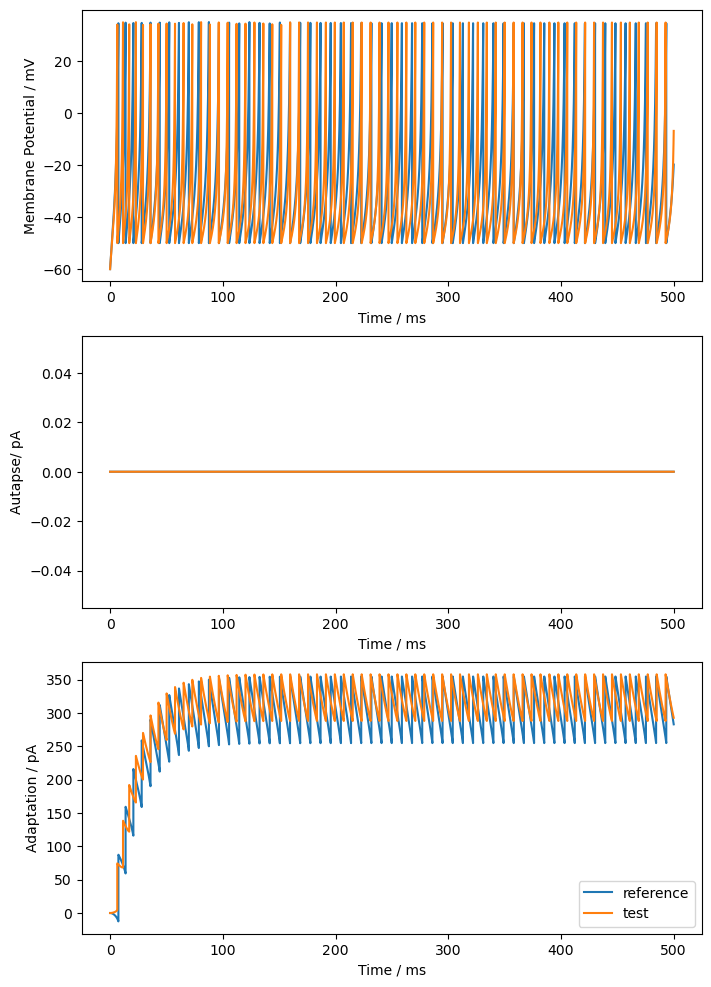

In [7]:
# Base autapse parameters

T = 500 # ms
dt = 0.01
N_iter = int(T/dt)

# injected current
I_h = 700
I_inj = I_h*np.ones((2, N_iter))

# initial cond.
x_ini = np.array([-60, 0, 0])
x_start = np.full((2, 3), fill_value = x_ini)
t_ini = np.array([0., 0.])

# create neuron
batch = batchAQUA([RS_ref, RS_test])
batch.Initialise(x_start, t_ini)

# simulate
X, time, spikes = batch.update_batch(dt, N_iter, I_inj)

# plot output
fig, ax = plt.subplots(3, 1, figsize = (8, 12))


ax[0].plot(time, X[0, 0, :], label = "reference")
ax[0].plot(time, X[1, 0, :], label = "test")
ax[0].set_xlabel("Time / ms")
ax[0].set_ylabel("Membrane Potential / mV")

ax[1].plot(time, X[0, 2, :], label = "reference")
ax[1].plot(time, X[1, 2, :], label = "test")
ax[1].set_xlabel("Time / ms")
ax[1].set_ylabel("Autapse/ pA")

ax[2].plot(time, X[0, 1, :], label = "reference")
ax[2].plot(time, X[1, 1, :], label = "test")
ax[2].set_xlabel("Time / ms")
ax[2].set_ylabel("Adaptation / pA")
plt.legend()